# M8 · Feature EDA — bridge to Phase 4

**Goal:** pull `marts.v_ml_features_driver_behavior` into pandas, sanity-check distributions, correlations, tenant-level stratification. **No modeling yet.**

**Exit criterion:** you can identify (a) redundant features, (b) features with near-zero variance, (c) apparent natural segments in a 2-D PCA/UMAP projection.


In [1]:
# === Setup ===
from __future__ import annotations
import sys, pathlib
# Make the src/ package importable even if pip install -e was skipped.
PROJECT_ROOT = pathlib.Path().resolve().parents[1] if pathlib.Path().resolve().name != 'accent-fleet-analytics' else pathlib.Path().resolve()
for candidate in (PROJECT_ROOT, PROJECT_ROOT.parent):
    src = candidate / 'src'
    if src.exists() and str(src) not in sys.path:
        sys.path.insert(0, str(src))
        break

from accent_fleet.config import settings
from accent_fleet.db import get_engine, transaction
from sqlalchemy import text

s = settings()
print(f"DB = {s.pg_user}@{s.pg_host}:{s.pg_port}/{s.pg_database}")
print(f"Schemas: staging={s.pg_schema_staging}, warehouse={s.pg_schema_warehouse}, marts={s.pg_schema_marts}")


DB = medali_dev@localhost:15432/accent_data
Schemas: staging=staging, warehouse=warehouse, marts=marts


## 2. Inputs — pull the feature table

In [2]:
import pandas as pd
with get_engine().connect() as conn:
    df = pd.read_sql(text('SELECT * FROM marts.v_ml_features_driver_behavior'), conn)
print(df.shape); df.head()


(23642, 39)


,tenant_id,device_id,year_month,vehicle_class_enc,total_trips,total_distance_km,avg_trip_distance_km,avg_trip_duration_minutes,avg_fuel_used_l,stddev_trip_distance,...,stops_per_trip,micro_stop_count,short_stop_count,medium_stop_count,long_stop_count,night_trip_ratio,weekend_trip_ratio,rush_hour_trip_ratio,active_days,avg_working_hours
0,235,425135,2019-11,1,106,2190.367641,20.663846,35.169811,0.0,30.176748,...,5.264151,452,41,18,41,0.141509,0.198113,0.254717,20,0.0
1,235,425253,2022-08,0,383,7121.173467,18.593142,21.485988,0.0,35.017939,...,1.104439,40,221,87,71,0.154047,0.023499,0.206266,22,0.0
2,264,436336,2024-09,0,63,140.396205,2.228511,7.360847,0.0,7.039227,...,1.222222,14,31,7,15,0.000000,0.079365,0.460317,14,0.0
3,235,425298,2024-02,0,491,4419.164740,9.000336,18.799389,0.0,12.596920,...,1.067210,33,334,119,35,0.006110,0.140530,0.254582,26,0.0
4,235,425209,2024-03,0,308,4318.831388,14.022180,18.595563,0.0,27.872694,...,1.139610,43,187,55,60,0.207792,0.188312,0.175325,22,0.0


## 3. Execute — EDA

In [3]:
# Distributions
import matplotlib.pyplot as plt
num = df.select_dtypes('number')
num.describe().T


,count,mean,std,min,25%,50%,75%,max
tenant_id,23642.0,572.751713,634.123826,235.000000,235.000000,238.000000,264.000000,1787.000000
device_id,23642.0,343619.528720,177319.039305,8401.000000,425116.000000,425233.000000,427658.000000,948864.000000
vehicle_class_enc,23642.0,0.560359,0.756355,0.000000,0.000000,0.000000,1.000000,2.000000
total_trips,23642.0,311.607647,191.839951,5.000000,191.000000,284.000000,395.000000,2865.000000
total_distance_km,23642.0,4465.333246,3075.876208,0.298111,2039.134458,3879.168925,6336.498024,26666.821542
avg_trip_distance_km,23642.0,17.297518,15.269689,0.042587,6.969909,14.547241,24.321787,724.236116
avg_trip_duration_minutes,23642.0,26.061774,217.682080,0.652381,13.680928,21.545361,30.790589,32726.839583
avg_fuel_used_l,23642.0,0.693723,2.329816,0.000000,0.000000,0.000000,0.000000,22.890110
stddev_trip_distance,23642.0,29.607317,42.644768,0.008647,10.257639,24.639632,38.445076,1594.155176
short_trip_ratio,23642.0,0.317728,0.155557,0.000000,0.202741,0.313585,0.415993,1.000000


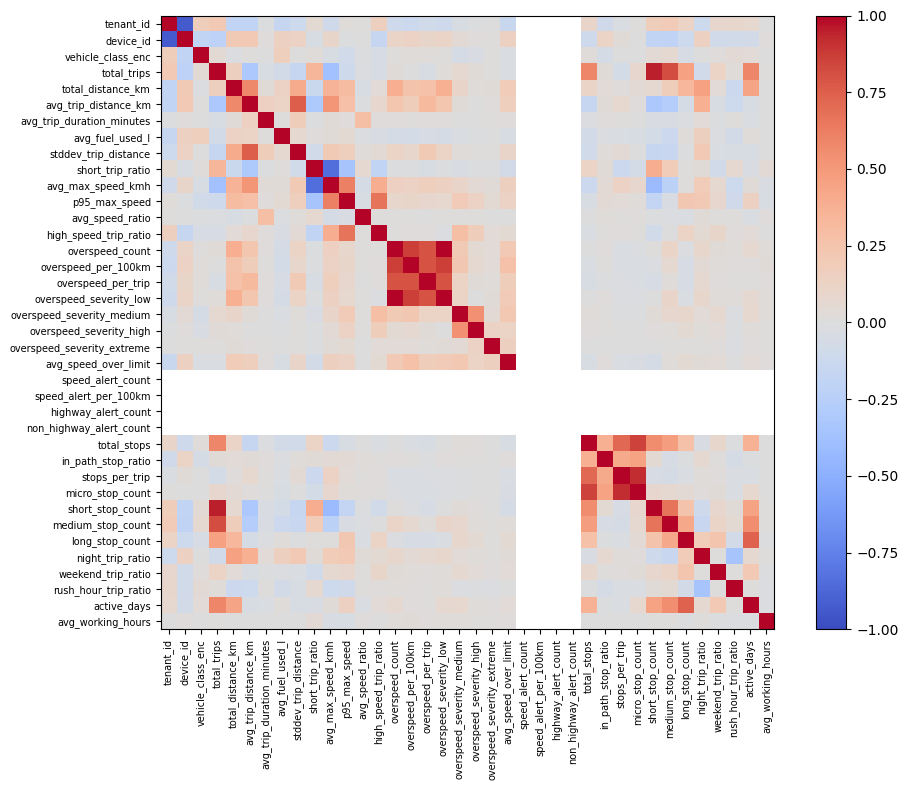

In [4]:
# Correlation heatmap
import numpy as np
import matplotlib.pyplot as plt
corr = df.select_dtypes('number').corr()
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns, fontsize=7)
fig.colorbar(im); plt.tight_layout(); plt.show()


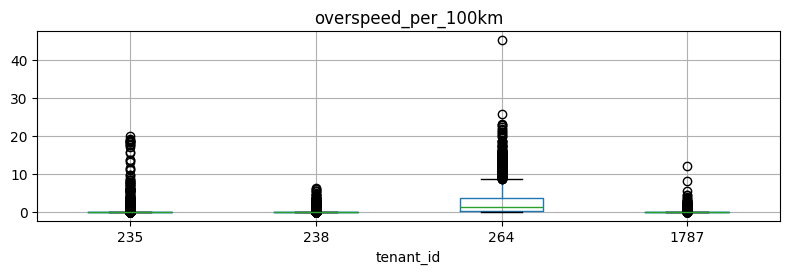

In [5]:
# Per-tenant distribution of a key feature
import matplotlib.pyplot as plt
if 'overspeed_per_100km' in df.columns and 'tenant_id' in df.columns:
    df.boxplot(column='overspeed_per_100km', by='tenant_id', figsize=(8,3))
    plt.suptitle(''); plt.tight_layout(); plt.show()


## 4. Inspect — write your notes here

### EDA notes

- …
- …
- …
